# Survival Analysis: Customer Churn & Retention EV

This notebook builds a three-stage survival analysis pipeline on a telco customer dataset to answer a single business question: 
**for which customers is a retention intervention worth the cost?**

I model time-to-churn as a survival problem: each customer has an observed tenure, and is either a churn event or right-censored (still active at study end). The pipeline runs KM, Cox PH, and Random Survival Forest, with each model producing progressively more personalised estimates of $\hat{S}(t|\mathbf{x}_i)$, the probability a customer is still active at time $t$.

The area under that curve is their expected remaining tenure, which we multiply by monthly revenue to get an individual LTV estimate, then use to decide whether intervening is worth it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import warnings # Suppress warnings for cleaner output
warnings.filterwarnings('ignore') 

There are a few target leakage columns we want to handle. However, also the dataset given is California only. If we want to be able to make more generalising assumptions about churning behaviour, we can't model this. Naturally, there could be local competitors as a signal that we are not modelling here.

In [2]:
df_raw = pd.read_excel('Telco_customer_churn.xlsx')
leakage = [
    'Churn Score', 'CLTV', 'Churn Label', 'Count',
    'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude'
] # Both columns that directly indicate churn, and columns we don't want to use for prediction
df = df_raw.drop(columns=leakage)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['CustomerID', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Reason']


In [3]:
n_before = len(df)
df = df[df['Churn Reason'] != 'Deceased'].copy() # We don't want to predict death
print(f"Dropped {n_before - len(df)} deceased customers. N = {len(df)}")

Dropped 6 deceased customers. N = 7037


In [4]:
df['event'] = df['Churn Value'].copy()
df.loc[df['Churn Reason'] == 'Moved', 'event'] = 0 # Moved customers are right-censored, not considered as churn events
# We did not observe their churning, so we can't say we saw their Time-to-churn

print(f"\nEvent=1 (voluntary churn): {df['event'].sum()}")
print(f"Event=0 (censored): {(df['event']==0).sum()}")


Event=1 (voluntary churn): 1810
Event=0 (censored): 5227


In [5]:
df['duration'] = df['Tenure Months'] # We will use tenure as the duration until churn or censoring
print(f"\nAdministrative cutoff: {df['duration'].max()} months")
print(f"Customers censored at cutoff (tenure=72): {(df['duration']==72).sum()}")


Administrative cutoff: 72 months
Customers censored at cutoff (tenure=72): 362


Technically the maximum observed duration is 72 months, making this our Censoring Time. Of course, these customers may churn afterwards, so this is our best estimate of Censoring Time.

Crucially, this is not explicitly modelled or an assumption of the model, but simply a fact about our data.

In [6]:
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method',]
num_cols = ['Monthly Charges', 'Total Charges']

feature_cols = cat_cols + num_cols
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce') # These will be nan only if tenure=0
df['Total Charges'] = df['Total Charges'].fillna(
    df['duration'] * df['Monthly Charges']
) # These will set Total Charges to zero where they should be.


In [7]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) # Encode categorical variables, treating unseen categories as -1
df_enc = df[feature_cols + ['duration', 'event']].copy()
df_enc[cat_cols] = enc.fit_transform(df[cat_cols])
category_mappings = {
    col: dict(enumerate(enc.categories_[i]))
    for i, col in enumerate(cat_cols)
}

print("Category mappings (for interpreting model outputs):")
for col, mapping in category_mappings.items():
    print(f"  {col}: {mapping}")

print(f"\nFeature matrix shape: {df_enc[feature_cols].shape}")
print(f"Events: {df_enc['event'].sum()}, Censored: {(df_enc['event']==0).sum()}")


Category mappings (for interpreting model outputs):
  Gender: {0: 'Female', 1: 'Male'}
  Senior Citizen: {0: 'No', 1: 'Yes'}
  Partner: {0: 'No', 1: 'Yes'}
  Dependents: {0: 'No', 1: 'Yes'}
  Phone Service: {0: 'No', 1: 'Yes'}
  Multiple Lines: {0: 'No', 1: 'No phone service', 2: 'Yes'}
  Internet Service: {0: 'DSL', 1: 'Fiber optic', 2: 'No'}
  Online Security: {0: 'No', 1: 'No internet service', 2: 'Yes'}
  Online Backup: {0: 'No', 1: 'No internet service', 2: 'Yes'}
  Device Protection: {0: 'No', 1: 'No internet service', 2: 'Yes'}
  Tech Support: {0: 'No', 1: 'No internet service', 2: 'Yes'}
  Streaming TV: {0: 'No', 1: 'No internet service', 2: 'Yes'}
  Streaming Movies: {0: 'No', 1: 'No internet service', 2: 'Yes'}
  Contract: {0: 'Month-to-month', 1: 'One year', 2: 'Two year'}
  Paperless Billing: {0: 'No', 1: 'Yes'}
  Payment Method: {0: 'Bank transfer (automatic)', 1: 'Credit card (automatic)', 2: 'Electronic check', 3: 'Mailed check'}

Feature matrix shape: (7037, 18)
Events:

## Kaplan-Meier

Kaplan-Meier is a nonparametric estimator of the population survival curve assuming no context data, and therefore nothing about the shape of $S(t)$. It gives every customer the same expected tenure (the area under the curve), which makes it a useful sanity-check baseline but not a scoring model. We also stratify by contract type and run a log-rank test to confirm the survival curves are significantly different across groups before building anything more complex.

Median survival time : inf months
E[T] (area under KM) : 54.8 months
Interpretation: the average customer, with no other information, is expected to remain active for ~55 months.


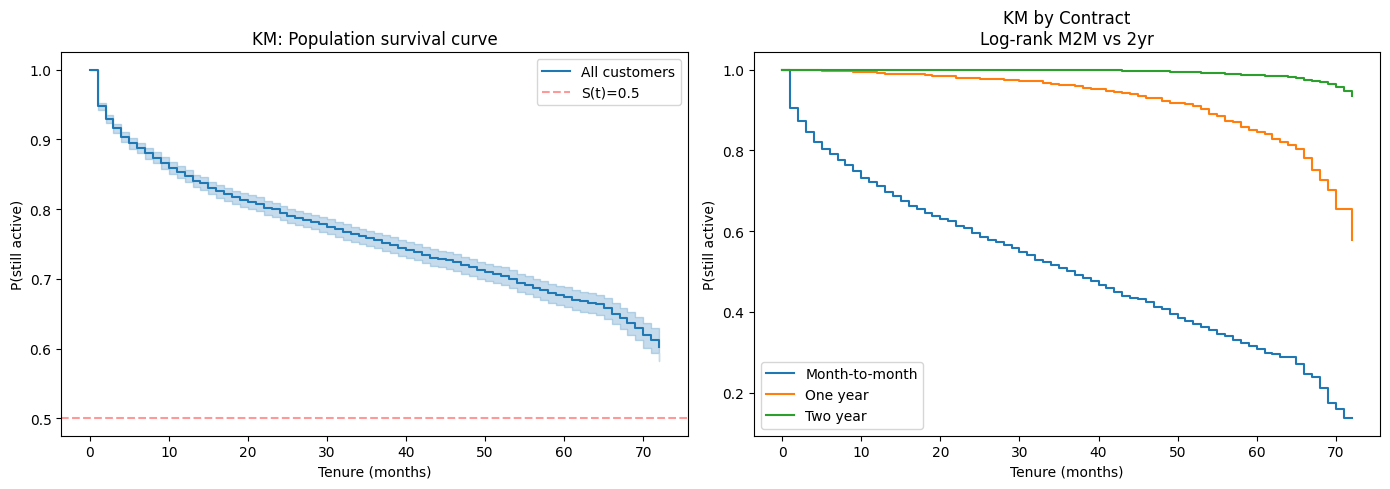

In [8]:
kmf = KaplanMeierFitter()
kmf.fit(df_enc['duration'], event_observed=df_enc['event'])

area_km = np.trapezoid(
    kmf.survival_function_.values.flatten(),
    kmf.survival_function_.index
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
kmf.plot_survival_function(ax=axes[0], ci_show=True, label='All customers')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.4, label='S(t)=0.5')
axes[0].set_title('KM: Population survival curve')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('P(still active)')
axes[0].legend()
print(f"Median survival time : {kmf.median_survival_time_:.0f} months")
print(f"E[T] (area under KM) : {area_km:.1f} months")
print("Interpretation: the average customer, with no other information, is expected to remain active for ~{:.0f} months.".format(area_km))

contract_col = df_enc['Contract']  # 0=Month-to-month, 1=One year, 2=Two year
contract_labels = category_mappings['Contract']

groups = {}
for val, label in contract_labels.items():
    mask = contract_col == val
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(df_enc['duration'][mask],
               event_observed=df_enc['event'][mask],
               label=label)
    kmf_g.plot_survival_function(ax=axes[1], ci_show=False)
    groups[val] = (df_enc['duration'][mask].values,
                   df_enc['event'][mask].values)

# Log-rank: month-to-month vs two-year
m2m_key = [k for k, v in contract_labels.items() if 'Month' in v][0]
tyr_key  = [k for k, v in contract_labels.items() if 'Two' in v][0]
lr = logrank_test(groups[m2m_key][0], groups[tyr_key][0],
                  event_observed_A=groups[m2m_key][1],
                  event_observed_B=groups[tyr_key][1])

axes[1].set_title(f'KM by Contract\nLog-rank M2M vs 2yr')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('P(still active)')

plt.tight_layout()
plt.show()

## Cox PH

Cox PH specifies the hazard as a product of an unspecified baseline $h_0(t)$ and a
parametric covariate term:

$$
h(t | \mathbf{x}_i) = h_0(t) \exp(\boldsymbol{\beta}^\top \mathbf{x}_i)
$$

$\boldsymbol{\beta}$ is estimated by maximising the partial likelihood, without ever specifying $h_0(t)$:

$$
\ell_p(\boldsymbol{\beta}) = \sum_{i:\, \delta_i=1} 
\left[ \boldsymbol{\beta}^\top \mathbf{x}_i - \log \sum_{j \in \mathcal{R}(t_i)} 
\exp(\boldsymbol{\beta}^\top \mathbf{x}_j) \right]
$$

where $\mathcal{R}(t_i)$ is the set of customers still active just before time $t_i$. 

Individual survival curves follow by plugging $\hat{\boldsymbol{\beta}}$ and an estimated $\hat{H}_0(t)$ into $\hat{S}(t | \mathbf{x}_i)$, which is just the negative exponential of cumulative hazard.

In [9]:
cox_df = df_enc.copy()

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col='duration', event_col='event')

cph.print_summary(decimals=3, columns=['coef', 'exp(coef)', 'p'])

<lifelines.CoxPHFitter: fitted with 7037 total observations, 5227 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7037
number of events observed = 1810
   partial log-likelihood = -13512.836
         time fit was run = 2026-04-27 18:23:33 UTC

---
                    coef exp(coef)       p
covariate                                 
Gender            -0.043     0.958   0.282
Senior Citizen     0.089     1.093   0.072
Partner           -0.255     0.775 <0.0005
Dependents        -0.648     0.523 <0.0005
Phone Service      0.062     1.064   0.410
Multiple Lines    -0.061     0.940   0.006
Internet Service  -0.024     0.976   0.459
Online Security   -0.280     0.756 <0.0005
Online Backup     -0.204     0.815 <0.0005
Device Protection -0.132     0.877 <0.0005
Tech Support      -0.238     0.788 <0.0005
Streaming TV      -0.017     0.983   0.468
Streaming Movies  -0.034     0.967   0.152
Contract          -0.706     0.494 <0.0005
Paperless Billing  0.256     1.292 <0.0005
Payment Method     0.167     1.181 <0.0005
Monthly Charges    0.011     1.011 <0.0005
Total Charges     -0.000     1.000 <0.0005
---
Concordance = 0.908
Partial AIC = 27061.672
log-likelihood ratio test = 3290.195 on 18 df
-log2(p) of ll-ratio test = inf

## Cox PH Assumption Check

Cox PH requires that for any two feature profiles $\mathbf{x}_i, \mathbf{x}_j$, the hazard ratio $\exp(\hat{\boldsymbol{\beta}}^\top(\mathbf{x}_i - \mathbf{x}_j))$ is constant over time. We test this formally via the Grambsch-Therneau test, built into this library. With $n > 7{,}000$ observations the test has high power to detect trivially small departures from PH that are substantively irrelevant, so we apply a Bonferroni-adjusted threshold of $\alpha = 0.01$ rather than the conventional $0.05$ to reduce false violations.

In [10]:
cph.check_assumptions(cox_df, p_value_threshold=0.01, show_plots=False)

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Dependents' failed the non-proportional test: p-value is 0.0001.

   Advice: with so few unique values (only 2), you can include `strata=['Dependents', ...]` in the
call in `.fit`. See documentation in link [E] below.

2. Variable 'Multiple Lines' failed the non-proportional test: p-value is 0.0001.

   Advice: with so few unique values (only 3), you can include `strata=['Multiple Lines', ...]` in
the call in `.fit`. See documentation in link [E] below.

3. Variable 'Streaming TV' failed the non-proportional test: p-value is 0.0013.

   Advice: with so few unique values (only 3), you can include `strata=['Streaming TV', ...]` in the
call in `.fit`. See documentation in link [E] below.

4. Variable 'Streaming Movies' failed the non-proportional test: p-value is 0.0055.

   Advice: with so few unique values (only 3), you can include `strata=['Streaming Movies', ...]` in
the call in `.fit`. See documentation in link [E] below.

5. Variable 'Contract' failed the non-proporti

[]

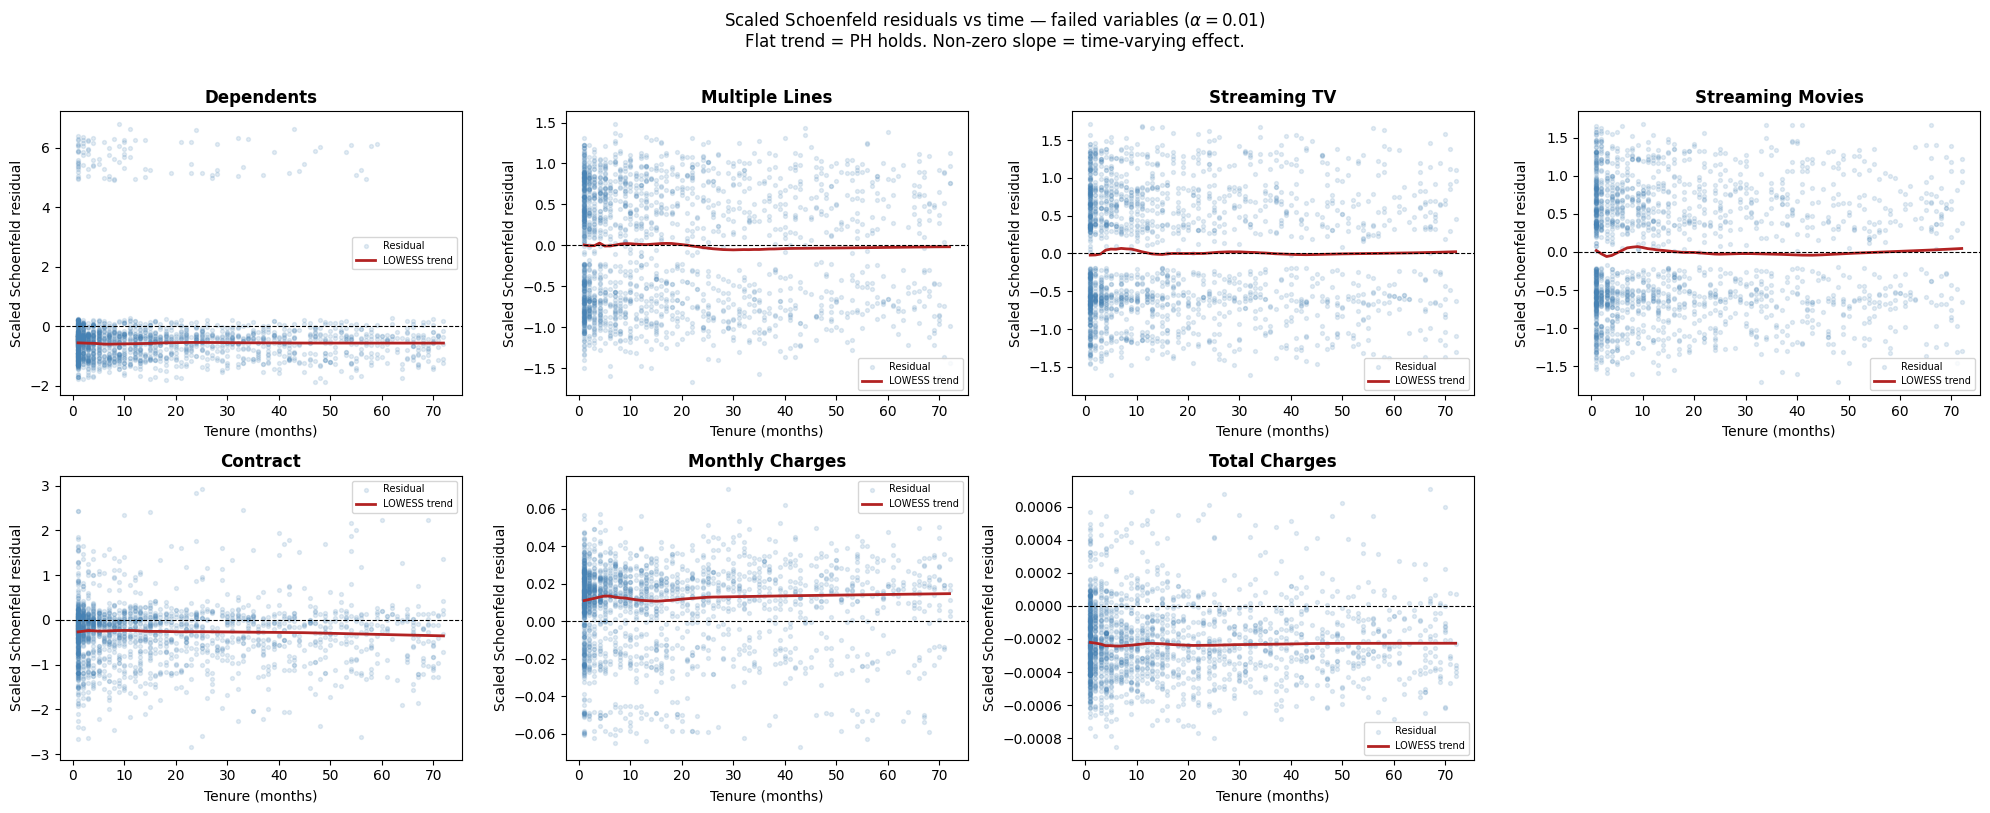

In [11]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Variables that failed at α=0.01 — these are the ones we'll stratify or drop
failed_vars = [
    'Dependents', 'Multiple Lines', 'Streaming TV',
    'Streaming Movies', 'Contract', 'Monthly Charges', 'Total Charges'
]

# Scaled Schoenfeld residuals: under PH, these should show no trend with time.
# A non-zero slope means beta_k(t) is drifting — the effect is time-varying.
residuals = cph.compute_residuals(cox_df, kind='scaled_schoenfeld')

# Align residuals with event times (residuals only exist at uncensored observations)
event_times = cox_df.loc[cox_df['event'] == 1, 'duration'].values

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, failed_vars):
    if col not in residuals.columns:
        ax.set_visible(False)
        continue

    r = residuals[col].values
    t = event_times[:len(r)]

    ax.scatter(t, r, alpha=0.15, s=8, color='steelblue', label='Residual')

    # LOWESS smooth — shows the trend β_k(t)
    smoothed = lowess(r, t, frac=0.4, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1],
            color='firebrick', linewidth=2, label='LOWESS trend')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Tenure (months)')
    ax.set_ylabel('Scaled Schoenfeld residual')
    ax.legend(fontsize=7)

# Hide the unused 8th panel
axes[-1].set_visible(False)

fig.suptitle(
    'Scaled Schoenfeld residuals vs time — failed variables ($\\alpha=0.01$)\n'
    'Flat trend = PH holds. Non-zero slope = time-varying effect.',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

Streaming Movies, Multiple Lines, Streaming TV, Monthly Charges, Total Charges show behaviour at the start of tenure. Contract shows a negative trend, Dependents shows a slight positive trend, that levels of near max tenure observed.

In [12]:
df_enc['log_monthly_charges'] = np.log1p(df_enc['Monthly Charges'])

# We remove total charges as this will violate proportional hazards, as it is an implicit tenure function
cox_df = df_enc.drop(columns=['Monthly Charges','Total Charges']).copy()

strata = ['Dependents', 'Multiple Lines', 'Streaming TV', 'Streaming Movies', 'Contract']

cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    cox_df,
    duration_col='duration',
    event_col='event',
    strata=strata
)

cph.print_summary(decimals=3, columns=['coef', 'exp(coef)', 'p'])


model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
penalizer,0.1
l1 ratio,0.0
strata,"[Dependents, Multiple Lines, Streaming TV, Str..."
baseline estimation,breslow
number of observations,7037
number of events observed,1810
partial log-likelihood,-8644.869
time fit was run,2026-04-27 18:23:34 UTC


In [13]:
cph.check_assumptions(cox_df, p_value_threshold=0.01, show_plots=False)


Proportional hazard assumption looks okay.


[]

## How we fix the Cox PH model violations

Seven features failed at $\alpha = 0.01$. `Total Charges` is dropped entirely: it is approximately $\text{tenure} \times \text{monthly charges}$, so its Schoenfeld residuals trend
mechanically with time by construction. `Monthly Charges` is log-transformed, which resolves its functional-form nonlinearity. The five remaining categorical violators `Dependents`, `Multiple Lines`, `Streaming TV`, `Streaming Movies`, and `Contract`, are moved into `strata`, giving each combination its own baseline hazard $h_{0k}(t)$ rather than forcing a single time-constant $\hat{\beta}_k$. The trade-off is that we lose point estimates for those features; their effect on churn is real but time-varying, which must be modelled with our hazard boosted trees, later

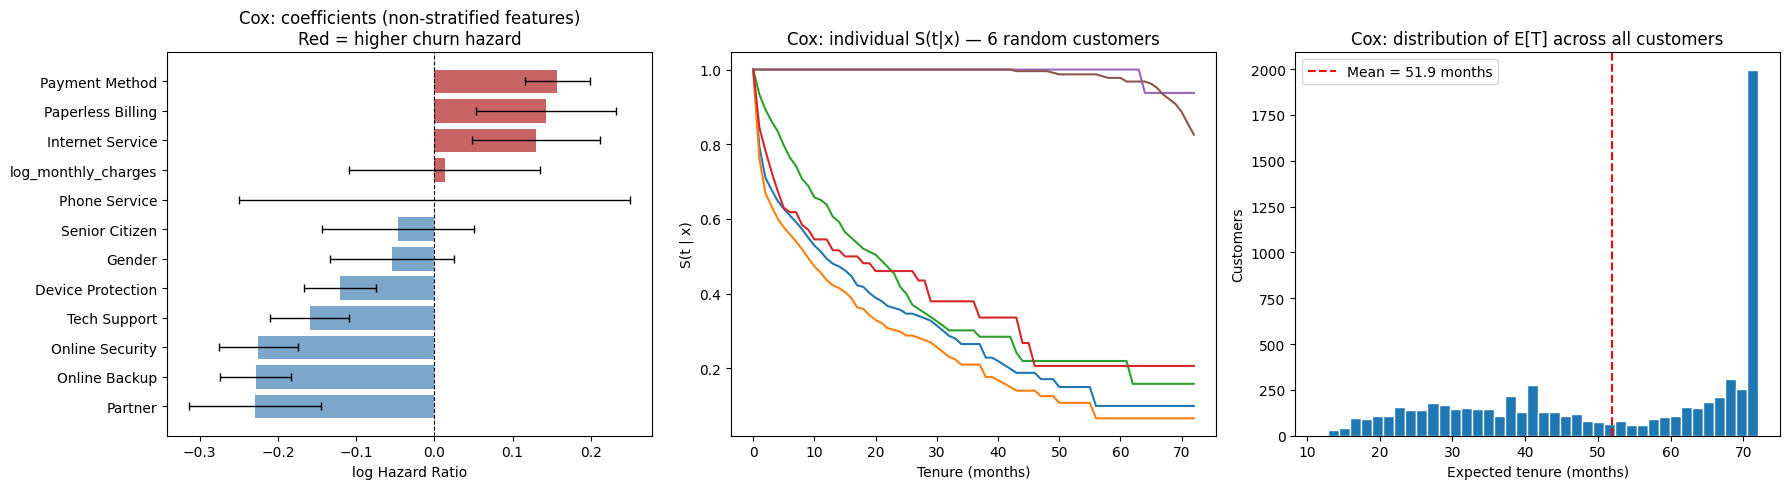

Cox E[T], mean: 51.9,  min: 11.4, max: 72.0 months


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
summary = cph.summary[['coef', 'exp(coef)', 'coef lower 95%', 'coef upper 95%', 'p']].copy()
summary = summary.sort_values('coef')

colors = ['firebrick' if c > 0 else 'steelblue' for c in summary['coef']]
axes[0].barh(summary.index, summary['coef'], color=colors, alpha=0.7)
axes[0].errorbar(
    summary['coef'], range(len(summary)),
    xerr=[summary['coef'] - summary['coef lower 95%'],
          summary['coef upper 95%'] - summary['coef']],
    fmt='none', color='black', capsize=3, linewidth=1
)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Cox: coefficients (non-stratified features)\nRed = higher churn hazard')
axes[0].set_xlabel('log Hazard Ratio')

sample = cox_df.sample(6, random_state=42)
cph.predict_survival_function(sample).plot(ax=axes[1], legend=False)
axes[1].set_title('Cox: individual S(t|x) — 6 random customers')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('S(t | x)')

cox_surv = cph.predict_survival_function(cox_df)
ev_cox = cox_surv.apply(lambda col: np.trapezoid(col.values, cox_surv.index))

axes[2].hist(ev_cox, bins=40, edgecolor='white')
axes[2].axvline(ev_cox.mean(), color='red', linestyle='--',
                label=f'Mean = {ev_cox.mean():.1f} months')
axes[2].set_title('Cox: distribution of E[T] across all customers')
axes[2].set_xlabel('Expected tenure (months)')
axes[2].set_ylabel('Customers')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Cox E[T], mean: {ev_cox.mean():.1f}, ",
      f"min: {ev_cox.min():.1f}, max: {ev_cox.max():.1f} months")

## Random Survival Forest

Cox PH requires the hazard ratio between any two customers to be constant over time, formally:

$$
h(t | \mathbf{x}_i) / h(t | \mathbf{x}_j) = \exp(\hat{\boldsymbol{\beta}}^\top(\mathbf{x}_i - \mathbf{x}_j))
$$
must not depend on $t$. The Schoenfeld diagnostics showed this fails for contract type, streaming services, and pricing — these features have stronger effects early in tenure and decay as customers habituate, so forcing a single $\hat{\beta}_k$ misrepresents them.

RSF makes no proportional hazards assumption. It grows $B$ survival trees, where each tree:
1. splits nodes by maximising the log-rank statistic between daughter groups
2. bootstraps the training data
3. randomly restricts candidate features at each split to $\sqrt{p}$ of the total. 

Each terminal node $\ell$ gets a Nelson-Aalen cumulative hazard estimate from its members:
$$
\hat{H}_\ell(t) = \sum_{t_{(j)} \leq t} \frac{d_j^{(\ell)}}{n_j^{(\ell)}}
$$

where $d_j^{(\ell)}$ and $n_j^{(\ell)}$ are events and at-risk counts at time $t_{(j)}$ within
that node. The ensemble prediction for customer $i$ averages across all trees:

$$
\hat{H}(t | \mathbf{x}_i) = \frac{1}{B} \sum_{b=1}^B \hat{H}_b(t | \mathbf{x}_i), \qquad \hat{S}(t | \mathbf{x}_i) = \exp\left(-\hat{H}(t | \mathbf{x}_i)\right)
$$

This produces a fully flexible individual survival curve: customers with different feature profiles can have qualitatively different curve shapes. Features stratified out of Cox re-enter here as regular features. We evaluate both models on held-out C-index: the probability that, given two customers, the model correctly ranks which one churns first.

In [15]:
rsf_feats = [c for c in df_enc.columns if c not in ['duration', 'event','Monthly Charges','Total Charges','log_monthly_charges']]
rsf_feats += ['Monthly Charges'] # We can keep Monthly Charges raw as Trees don't need smooth ranges

X = df_enc[rsf_feats].values
y = Surv.from_arrays(df_enc['event'].values.astype(bool),
                        df_enc['duration'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=df_enc['event']
)

rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=67
)
rsf.fit(X_train, y_train)

,n_estimators,300
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,67


In [16]:
rsf_cindex = rsf.score(X_test, y_test)

X_test_df  = pd.DataFrame(X_test, columns=rsf_feats)

# Compare Cox and RSF predictions on the test set using concordance index
# Ensure Cox sees the same input as it expects
X_test_cox = X_test_df.copy()
X_test_cox['log_monthly_charges'] = np.log1p(X_test_cox['Monthly Charges'])
X_test_cox = X_test_cox.drop(columns=['Monthly Charges'])


strata_vals = df_enc[strata].iloc[
    df_enc.index.get_indexer(
        df_enc.sample(frac=1, random_state=67).index
    )[-len(X_test):]
].values
for i, s in enumerate(strata):
    X_test_cox[s] = strata_vals[:, i]
cox_risk   = cph.predict_partial_hazard(X_test_cox)
cox_cindex = concordance_index_censored(
    y_test['event'], y_test['time'], cox_risk.values
)[0]

print(f"C-index  |  Cox: {cox_cindex:.3f}   RSF: {rsf_cindex:.3f}")
print("(0.5 = random, 1.0 = perfect)")

C-index  |  Cox: 0.806   RSF: 0.848
(0.5 = random, 1.0 = perfect)


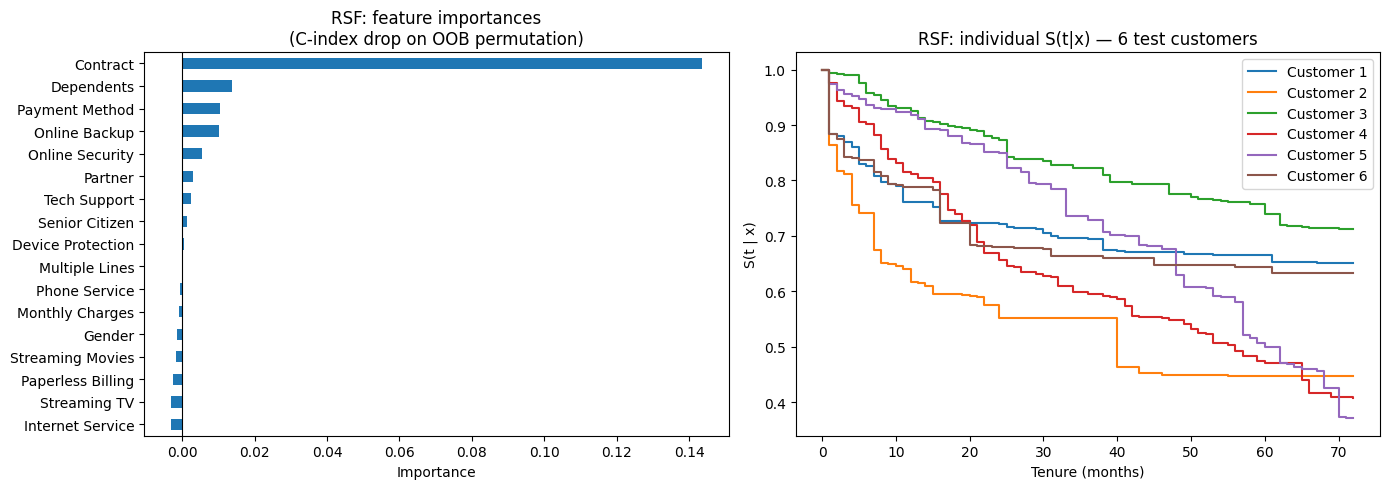

In [17]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rsf, X_test, y_test,
    n_repeats=10,
    random_state=67,
    n_jobs=-1
)

importances = pd.Series(
    perm.importances_mean, index=rsf_feats
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importances.plot.barh(ax=axes[0])
axes[0].set_title('RSF: feature importances\n(C-index drop on OOB permutation)')
axes[0].set_xlabel('Importance')
axes[0].axvline(0, color='black', linewidth=0.8)

surv_fns_sample = rsf.predict_survival_function(X_test[:6])
for i, fn in enumerate(surv_fns_sample):
    axes[1].step(fn.x, fn(fn.x), where='post', label=f'Customer {i+1}')
axes[1].set_title('RSF: individual S(t|x) — 6 test customers')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('S(t | x)')
axes[1].legend()

plt.tight_layout()
plt.show()


## Expected Value of Intervention

Each customer's survival curve integrates to an expected remaining tenure:
$$
\mathbb{E}[T_i] = \int_0^\infty \hat{S}(t | \mathbf{x}_i) dt,
$$

which, multiplied by monthly revenue $r_i$, gives a base LTV:

$$
\text{LTV}_i = r_i \cdot \mathbb{E}[T_i]
$$

A retention intervention shifts the hazard multiplicatively by $\gamma \in (0,1)$: 
$$
h_\text{int}(t | \mathbf{x}_i) = \gamma \cdot h(t | \mathbf{x}_i).
$$

Since $\hat{S}(t) = \exp(-\hat{H}(t))$, halving the cumulative hazard raises the survival curve to a power:

$$
\hat{S}_\text{int}(t | \mathbf{x}_i) = \hat{S}(t | \mathbf{x}_i)^\gamma
$$

The net EV gain from intervening on customer $i$ at cost $c$ is then:

$$
\Delta_i(\gamma) = r_i \int_0^\infty \left[\hat{S}(t | \mathbf{x}_i)^\gamma - \hat{S}(t | \mathbf{x}_i)\right] dt - c
$$

The integral term is the expected months gained; dividing by $r_i$ gives the break-even tenure gain $c / r_i$. A high-revenue customer on £100/month needs only 0.5 months gained to justify a £50 intervention; a low-revenue customer on £25/month needs 2 months. Because we have no A/B test, we do not commit to a single $\gamma$. Instead we test three scenarios:
1. weak ($\gamma = 0.9$)
2. moderate ($\gamma = 0.75$)
3. strong ($\gamma = 0.5$),

assigning customer a tier based on how many scenarios return $\Delta_i > 0$. Tier 1 customers are worth intervening on even if the intervention barely works; Tier 4 customers are not worth the cost under any realistic assumption.

In [18]:
surv_all = rsf.predict_survival_function(X)
time_grid = surv_all[0].x
S_matrix = np.vstack([fn(time_grid) for fn in surv_all])


expected_tenure = np.trapezoid(S_matrix, time_grid, axis=1)
monthly_revenue = df_enc['Monthly Charges'].values
ltv_base = monthly_revenue * expected_tenure

In [19]:
cost   = 50 # Arbitrary cost of intervention (e.g. retention offer)
# This can be generalised to be customer-specific, but we'll keep it simple here

gammas = {'weak': 0.9, 'moderate': 0.75, 'strong': 0.5}

ev_results = pd.DataFrame({
    'CustomerID'      : df['CustomerID'].values,
    'Monthly Charges' : monthly_revenue,
    'Contract'        : df['Contract'].values,
    'duration'        : df_enc['duration'].values,
    'event'           : df_enc['event'].values,
    'E_tenure_months' : expected_tenure,
    'LTV_base'        : ltv_base,
})

for label, gamma in gammas.items():
    S_int      = S_matrix ** gamma
    tenure_int = np.trapezoid(S_int, time_grid, axis=1)
    ltv_int    = monthly_revenue * tenure_int - cost
    ev_results[f'delta_{label}']     = ltv_int - ltv_base
    ev_results[f'intervene_{label}'] = (ev_results[f'delta_{label}'] > 0).astype(int) # Does longer tenure give returns?


In [20]:
def assign_tier(row):
    # Intervention tiers, from weakest tenure gain to strongest.
    # So Tier 1 means even if tenure is moderately increased, we seek to gain revenue
    # But Tier 4 means even if tenure gained is strong, we cannot gain revenue.
    if row['intervene_weak'] == 1:
        return 'Tier 1'
    elif row['intervene_moderate'] == 1:
        return 'Tier 2'
    elif row['intervene_strong'] == 1:
        return 'Tier 3'
    else:
        return 'Tier 4'

ev_results['tier'] = ev_results.apply(assign_tier, axis=1) # Assign intervention tiers based on scenarios passed for each customer

print("Tier breakdown ===")
print(ev_results['tier'].value_counts())


Tier breakdown ===
tier
Tier 1    3627
Tier 4    1723
Tier 2    1176
Tier 3     511
Name: count, dtype: int64


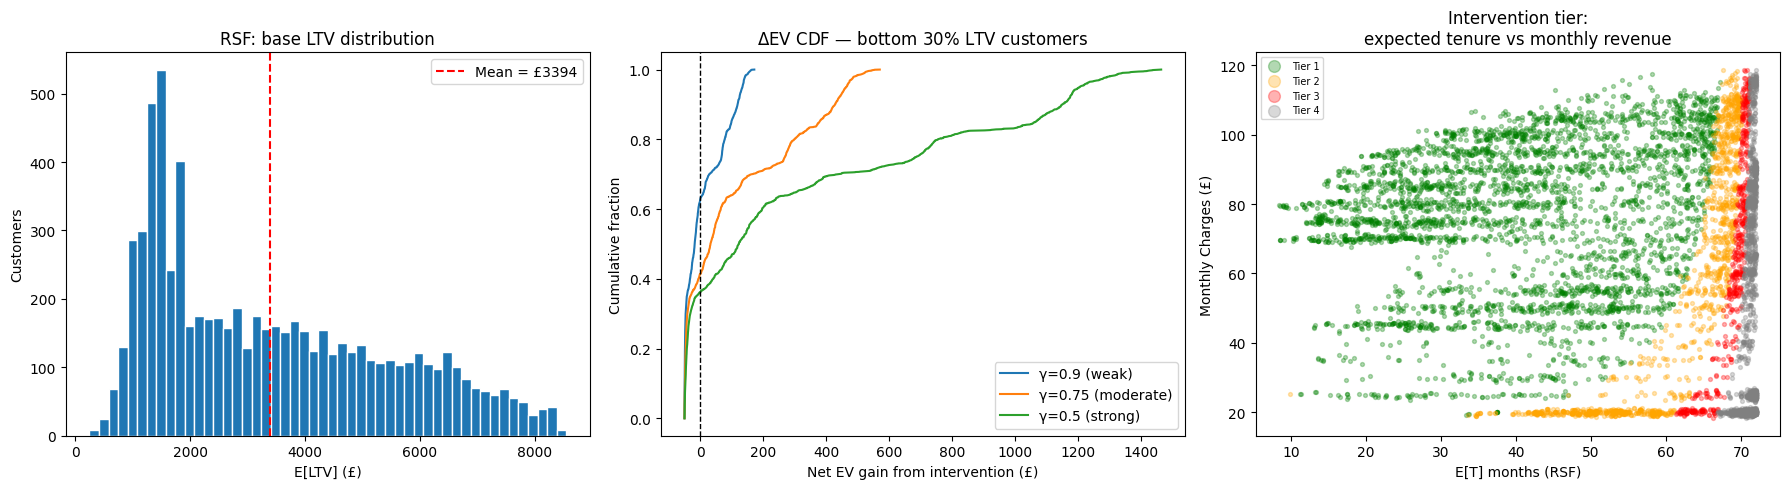

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LTV distribution
axes[0].hist(ltv_base, bins=50, edgecolor='white')
axes[0].axvline(ltv_base.mean(), color='red', linestyle='--',
                label=f'Mean = £{ltv_base.mean():.0f}')
axes[0].set_title('RSF: base LTV distribution')
axes[0].set_xlabel('E[LTV] (£)')
axes[0].set_ylabel('Customers')
axes[0].legend()

# Delta EV CDF for bottom-30% LTV customers
risky_mask = ltv_base < np.percentile(ltv_base, 30)
for label, gamma in gammas.items():
    vals = np.sort(ev_results.loc[risky_mask, f'delta_{label}'])
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    axes[1].plot(vals, cdf, label=f'γ={gamma} ({label})')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(r'$\Delta$EV CDF — bottom 30% LTV customers')
axes[1].set_xlabel('Net EV gain from intervention (£)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].legend()

tier_colours = {
    'Tier 1': 'green',
    'Tier 2' : 'orange',
    'Tier 3' : 'red',
    'Tier 4' : 'grey',
}
for tier, colour in tier_colours.items():
    mask = ev_results['tier'] == tier
    axes[2].scatter(
        ev_results.loc[mask, 'E_tenure_months'],
        ev_results.loc[mask, 'Monthly Charges'],
        c=colour, alpha=0.3, s=8,
        label=tier.split('—')[0].strip()
    )
axes[2].set_title('Intervention tier:\nexpected tenure vs monthly revenue')
axes[2].set_xlabel('E[T] months (RSF)')
axes[2].set_ylabel('Monthly Charges (£)')
axes[2].legend(markerscale=3, fontsize=7)

plt.tight_layout()
plt.show()


In [ ]:
print(f"\n E[T] across models")
print(f"KM (population average): {area_km:.1f} months")
print(f"Cox (individual, mean): {ev_cox.mean():.1f} months")
print(f"RSF (individual, mean): {expected_tenure.mean():.1f} months")


print(f"\nMonthly revenue at stake by tier")
for tier in ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']:
    mask = ev_results['tier'] == tier
    mrr  = ev_results.loc[mask, 'Monthly Charges'].sum()
    n = mask.sum()
    print(f"{tier}: {n:>4} customers  |  £{mrr:>8,.0f}/month MRR")


 E[T] across models
KM (population average): 54.8 months
Cox (individual, mean): 51.9 months
RSF (individual, mean): 53.7 months

Monthly revenue at stake by tier
Tier 1: 3627 customers  |  £ 275,726/month MRR
Tier 2: 1176 customers  |  £  67,451/month MRR
Tier 3:  511 customers  |  £  33,285/month MRR
Tier 4: 1723 customers  |  £  79,244/month MRR
